# Executive Summary: Healthcare Cost & Patient Risk Factor Analysis
This analysis utilizes Ordinary Least Squares (OLS) regression to isolate the primary drivers of healthcare insurance costs across 1,338 policyholders. 

The model identified **Smoking Status** as the most significant financial risk factor, associated with a **&#36;23,847** increase in annual charges, followed by **BMI** (**&#36;339** per unit increase).

These insights provide a statistical foundation for understanding cost drivers
across patient demographics and improved cost forecasting strategies.

In [2]:
import pandas as pd
insurance = pd.read_csv("insurance.csv")

In [3]:
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
insurance.columns = insurance.columns.str.title()

In [5]:
insurance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       1338 non-null   int64  
 1   Sex       1338 non-null   object 
 2   Bmi       1338 non-null   float64
 3   Children  1338 non-null   int64  
 4   Smoker    1338 non-null   object 
 5   Region    1338 non-null   object 
 6   Charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
insurance.duplicated().sum()

1

In [7]:
insurance[insurance.duplicated(keep=False)]

,Age,Sex,Bmi,Children,Smoker,Region,Charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


In [8]:
insurance.drop_duplicates(inplace = True)

In [9]:
insurance.isnull().sum()

Age         0
Sex         0
Bmi         0
Children    0
Smoker      0
Region      0
Charges     0
dtype: int64

In [10]:
print(insurance['Sex'].value_counts())
print(insurance['Children'].value_counts())
print(insurance['Smoker'].value_counts())
print(insurance['Region'].value_counts())

Sex
male      675
female    662
Name: count, dtype: int64
Children
0    573
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64
Smoker
no     1063
yes     274
Name: count, dtype: int64
Region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


In [11]:
insurance.describe()

,Age,Bmi,Children,Charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


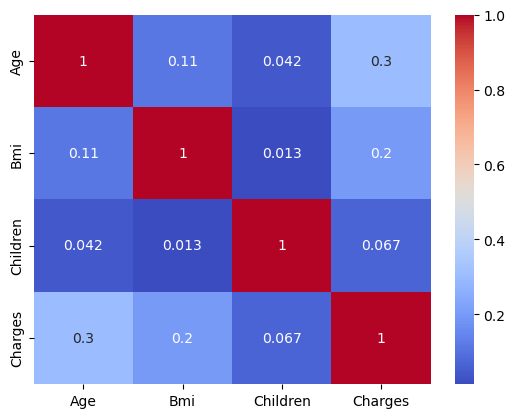

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(insurance.corr(numeric_only = True), annot = True, cmap = 'coolwarm')
plt.show()

Age and BMI show the strongest positive correlations with charges among numeric variables (0.30 and 0.20 respectively). Children has a weak relationship (0.07), suggesting it is not a meaningful cost driver on its own.

<Axes: xlabel='Sex', ylabel='Charges'>

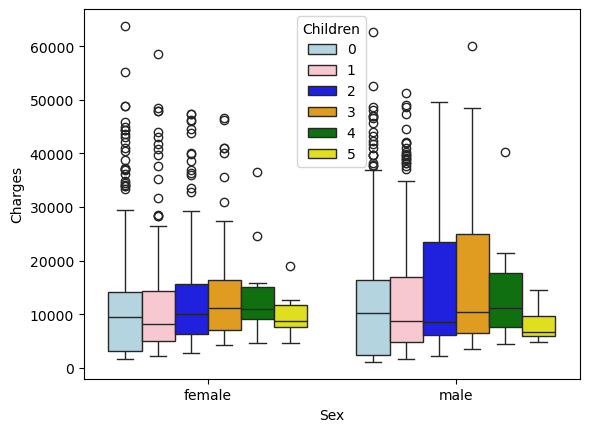

In [14]:
sns.boxplot(x = 'Sex', y = 'Charges', data = insurance, hue = 'Children', palette =['lightblue', 'pink', 'blue', 'orange', 'green', 'yellow'])

Charge distributions overlap across sex and number of children, with wide variance in all groups. This suggests these variables have limited standalone predictive power.

<Axes: xlabel='Smoker', ylabel='Charges'>

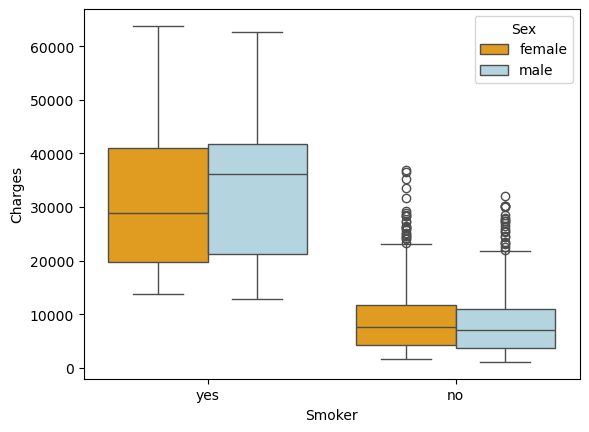

In [16]:
sns.boxplot(x = 'Smoker', y = 'Charges', data = insurance, hue = 'Sex', palette = ['orange', 'lightblue'])

Smokers incur dramatically higher charges regardless of sex, with median costs roughly 3–4x higher than non-smokers. This visual motivates smoking status as the model's dominant predictor.

In [18]:
insurance_encoded = pd.get_dummies(insurance, columns = ['Sex', 'Smoker', 'Region'], drop_first = True)

In [19]:
insurance_encoded

,Age,Bmi,Children,Charges,Sex_male,Smoker_yes,Region_northwest,Region_southeast,Region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,True,False,True,False,False
1334,18,31.920,0,2205.98080,False,False,False,False,False
1335,18,36.850,0,1629.83350,False,False,False,True,False
1336,21,25.800,0,2007.94500,False,False,False,False,True


In [20]:
from sklearn.linear_model import LinearRegression

In [21]:
X = insurance_encoded.drop('Charges', axis = 1)
Y = insurance_encoded['Charges']

In [22]:
model = LinearRegression()
model.fit(X, Y)

LinearRegression()

In [23]:
print(f"Intercept: {model.intercept_:.2f}")
print("Coefficients:", model.coef_)

Intercept: -11936.56
Coefficients: [  256.76461078   339.2503637    474.8204855   -129.48147837
 23847.32884379  -349.22653156 -1035.26560176  -960.08138547]


In [24]:
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
coeff_df

,Coefficient
Age,256.764611
Bmi,339.250364
Children,474.820486
Sex_male,-129.481478
Smoker_yes,23847.328844
Region_northwest,-349.226532
Region_southeast,-1035.265602
Region_southwest,-960.081385


In [25]:
import statsmodels.api as sm
import numpy as np

X = X.astype(float)
Y = Y.astype(float)

X = sm.add_constant(X)

model = sm.OLS(Y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                Charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.0
Date:                Wed, 25 Mar 2026   Prob (F-statistic):               0.00
Time:                        16:03:30   Log-Likelihood:                -13538.
No. Observations:                1337   AIC:                         2.709e+04
Df Residuals:                    1328   BIC:                         2.714e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.194e+04    988.227  

## Conclusion:
The OLS regression model explains approximately 75% of the variance in insurance charges (R² = 0.751). Smoking status is by far the most significant cost driver (+**&#36;23,847**), followed by BMI (+**&#36;339/unit**) and age (+**&#36;257/year**). Sex, region, and number of children contribute minimally by comparison.

These findings suggest that  smoking status and BMI are the dominant cost drivers, outweighing demographic variables like sex, region, and number of children.